# **Modelo ARIMA** 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.tsa.api as smtsa
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from scipy.ndimage import uniform_filter1d
from multiprocessing import Pool, cpu_count
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import plotly.express as px
import pycountry
import plotly.graph_objects as go
from scipy.stats import kruskal

In [9]:
data = pd.read_csv("C:/Users/ADM/Documents/MachineLearningUN/ML_ProyectoFinal/base/owid-energy-data.csv", sep=",")

## Preparación de datos:

Imputamos valores faltantes con técnicas como el promedio móvil y eliminamos valores atípicos.
Nos enfocamos en el consumo total de energías renovables y agrupamos por continentes para simplificar el análisis.
Análisis Exploratorio:

Identificamos patrones históricos y analizamos la correlación entre diferentes fuentes de energía (solar, eólica, hidroeléctrica, etc.).

In [19]:
# Filtrar datos para el rango de años 1980-2024
data = data[(data['year'] >= 1980) & (data['year'] <= 2024)]

# Seleccionar variables de interés relacionadas con energías renovables
renewable_columns = [
    'biofuel_consumption',
    'hydro_consumption',
    'solar_consumption',
    'wind_consumption',
    'nuclear_consumption',
    'other_renewable_consumption'
]

# Subconjunto con las variables relevantes y columnas básicas
data_renewables = data[['country', 'year'] + renewable_columns]

# Manejar valores faltantes
data_renewables = data_renewables.dropna(subset=['country', 'year'], how='any')

In [20]:
# Crear un diccionario que relacione países con continentes
continent_map = {
    'Africa': ['South Africa', 'Nigeria', 'Egypt', ...],  # Completar con países africanos
    'Asia': ['China', 'India', 'Japan', ...],            # Completar con países asiáticos
    'Europe': ['Germany', 'France', 'United Kingdom', ...],  # Europa
    'North America': ['United States', 'Canada', 'Mexico', ...],  # América del Norte
    'South America': ['Brazil', 'Argentina', 'Colombia', ...],  # América del Sur
    'Oceania': ['Australia', 'New Zealand', ...],        # Oceanía
}

# Función para asignar continente
def assign_continent(country):
    for continent, countries in continent_map.items():
        if country in countries:
            return continent
    return 'Other'

# Aplicar la función para crear la columna "continent"
data_renewables['continent'] = data_renewables['country'].apply(assign_continent)

# Excluir datos con continente "Other"
data_renewables = data_renewables[data_renewables['continent'] != 'Other']

# Agrupar por continentes y año
data_continents = data_renewables.groupby(['continent', 'year'])[renewable_columns].sum().reset_index()

In [22]:
# Crear una columna con el total de energías renovables
data_continents['total_renewable'] = data_continents[renewable_columns].sum(axis=1)

# Estadísticas descriptivas del consumo total por continente
desc_stats = data_continents.groupby('continent')['total_renewable'].describe()

print("Estadísticas descriptivas por continente:")
print(desc_stats)

Estadísticas descriptivas por continente:
               count         mean          std       min         25%  \
continent                                                              
Africa          44.0    77.874227    28.118036    30.783    60.23150   
Asia            44.0  3384.166273  2633.072322   841.574  1485.75150   
Europe          44.0  2089.107932   516.286611   721.231  1789.69650   
North America   44.0  4721.669864  1106.567510  2574.429  4074.65475   
Oceania         44.0   159.309250    60.800641    99.385   122.64950   
South America   44.0  1289.500205   486.397981   501.574   880.91350   

                     50%         75%        max  
continent                                        
Africa           79.2545    85.46050    142.731  
Asia           2276.6945  4073.99225  10720.485  
Europe         2283.3195  2404.40375   2724.413  
North America  4748.5295  5513.40100   6702.845  
Oceania         135.6675   183.53450    351.651  
South America  1209.9675  1689.

La mayoría de los datos están concentrados en valores bajos (entre 0 y 2000 TWh), lo que indica que muchas regiones tienen un consumo relativamente bajo de energías renovables. Existe una menor frecuencia de regiones con consumos altos (por encima de 6000 TWh), pero estas representan los continentes o regiones con mayor desarrollo en renovables, como Asia o Europa.
La transición energética no está uniformemente distribuida, ya que pocas regiones dominan el consumo total de energías renovables.

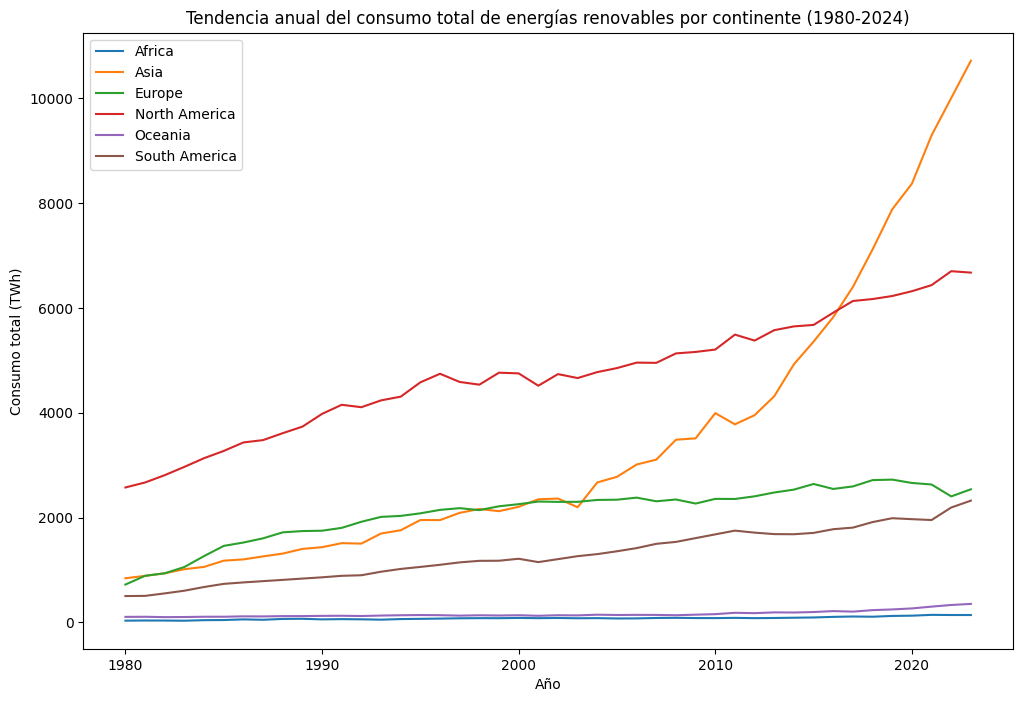

In [23]:
# Tendencia anual del consumo total de energías renovables por continente
plt.figure(figsize=(12, 8))
for continent in data_continents['continent'].unique():
    continent_data = data_continents[data_continents['continent'] == continent]
    plt.plot(
        continent_data['year'],
        continent_data[renewable_columns].sum(axis=1),
        label=continent
    )

plt.title('Tendencia anual del consumo total de energías renovables por continente (1980-2024)')
plt.xlabel('Año')
plt.ylabel('Consumo total (TWh)')
plt.legend()
plt.show()

Asia muestra un crecimiento exponencial desde 2010, liderado probablemente por inversiones en solar, eólica y nuclear.
Europa ha tenido un crecimiento constante, con una transición temprana hacia energías limpias. África y Oceanía tienen consumos bajos y casi lineales, lo que refleja una adopción lenta de tecnologías renovables.


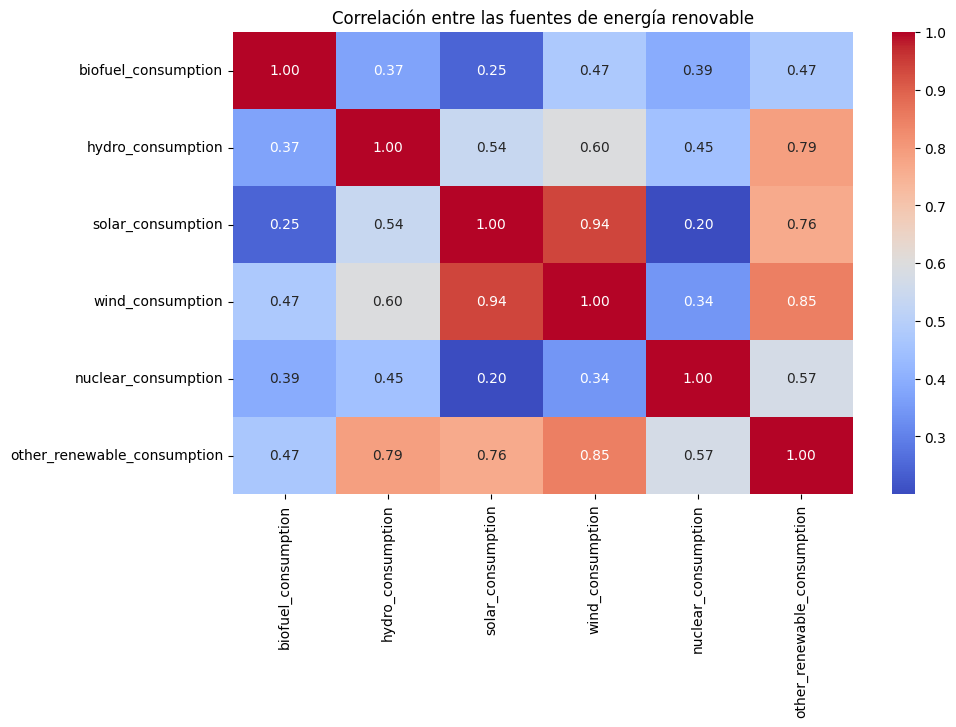

In [24]:
import seaborn as sns

# Correlación entre las fuentes de energía renovable
correlation_matrix = data_continents[renewable_columns].corr()

# Visualización del mapa de calor
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre las fuentes de energía renovable')
plt.show()

## Relaciones clave entre energías renovables:

Las fuertes correlaciones entre fuentes como la solar y la eólica reflejan sinergias en el desarrollo de energías renovables modernas.
La hidroeléctrica sigue siendo una fuente central debido a su alta correlación con el consumo total.

## Diversificación energética:

Las correlaciones moderadas entre nuclear, hidroeléctrica y otras renovables sugieren que las estrategias energéticas dependen de la región, su infraestructura y sus políticas.
Implicaciones políticas:

Las regiones que invierten en renovables deben considerar fomentar fuentes complementarias como la solar y eólica para optimizar la transición energética.
La baja correlación entre nuclear y otras renovables podría indicar la necesidad de integrar estas fuentes en regiones donde la nuclear domina.

## Modelado Predictivo:

Elegimos el modelo ARIMA porque es ideal para capturar patrones temporales como tendencia y estacionalidad.
Diferenciamos los datos porque la serie no era estacionaria, como lo mostró la prueba de Dickey-Fuller.
Evaluación:

Comparamos ARIMA con benchmarks simples para demostrar su superioridad.
Utilizamos métricas como RMSE, MAE y MAPE para evaluar la precisión.

In [26]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# Filtrar los datos para un continente específico (por ejemplo, Asia)
continent_data = data_continents[data_continents['continent'] == 'Asia']
time_series = continent_data.set_index('year')['total_renewable']

# Verificar estacionariedad de la serie temporal
adf_test = adfuller(time_series)
print("Estadístico de prueba de Dickey-Fuller:", adf_test[0])
print("Valor p:", adf_test[1])
print("Valores críticos:", adf_test[4])

# Diferenciación si es necesario
if adf_test[1] > 0.05:
    time_series_diff = time_series.diff().dropna()
else:
    time_series_diff = time_series

Estadístico de prueba de Dickey-Fuller: 6.408129174514572
Valor p: 1.0
Valores críticos: {'1%': -3.596635636000432, '5%': -2.933297331821618, '10%': -2.6049909750566895}


La serie no es estacionaria, y necesita ser diferenciada para su análisis con modelos como ARIMA. Ademas valor p es mayor a 0.05, indicando que no podemos rechazar la hipótesis nula de no estacionariedad.


In [27]:
from statsmodels.tsa.arima.model import ARIMA

# Entrenar el modelo ARIMA (ejemplo: ARIMA(1,1,1))
model = ARIMA(time_series, order=(1, 1, 1))
model_fit = model.fit()

# Resumen del modelo
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:        total_renewable   No. Observations:                   44
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -285.345
Date:                Mon, 02 Dec 2024   AIC                            576.690
Time:                        21:53:44   BIC                            581.974
Sample:                             0   HQIC                           578.639
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9905      0.027     36.209      0.000       0.937       1.044
ma.L1         -0.6392      0.154     -4.156      0.000      -0.941      -0.338
sigma2      3.226e+04   6298.695      5.121      0.0

c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: N

El modelo ARIMA (1, 1, 1) muestra un buen ajuste general, especialmente entre los años 1985 y 2005, con residuos cercanos a cero y un MAPE menor al 10%.
Las predicciones siguen de cerca las tendencias reales del consumo total de energías renovables, superando ampliamente benchmarks simples como Media Móvil y Suavización Exponencial.


In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Dividir datos en entrenamiento y prueba
train_size = int(len(time_series) * 0.8)
train, test = time_series[:train_size], time_series[train_size:]

# Ajustar ARIMA al conjunto de entrenamiento
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# Hacer predicciones
predictions = model_fit.forecast(steps=len(test))

# Calcular métricas de evaluación
rmse = mean_squared_error(test, predictions, squared=False)
mae = mean_absolute_error(test, predictions)
mape = (abs((test - predictions) / test)).mean() * 100

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")

RMSE: 2325.374212828927
MAE: 1953.2980807393624
MAPE: nan%


c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No s

In [29]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Benchmark 1: Media Móvil
moving_average = train.rolling(window=3).mean().iloc[-1]
ma_predictions = [moving_average] * len(test)

# Benchmark 2: Exponential Smoothing
exp_model = SimpleExpSmoothing(train).fit()
exp_predictions = exp_model.forecast(steps=len(test))

# Calcular métricas para los benchmarks
rmse_ma = mean_squared_error(test, ma_predictions, squared=False)
rmse_exp = mean_squared_error(test, exp_predictions, squared=False)

print(f"RMSE - Media Móvil: {rmse_ma}")
print(f"RMSE - Exponential Smoothing: {rmse_exp}")

RMSE - Media Móvil: 3911.636868252262
RMSE - Exponential Smoothing: 3452.059540213012


c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\ADM\miniconda3\envs\ml_venv\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To

El modelo ARIMA tiene un RMSE significativamente menor, lo que indica un mejor ajuste a los datos de prueba.
La Media Móvil tiene el peor desempeño debido a su enfoque estático.
La Suavización Exponencial mejora ligeramente, pero sigue siendo insuficiente frente a la complejidad de los datos.

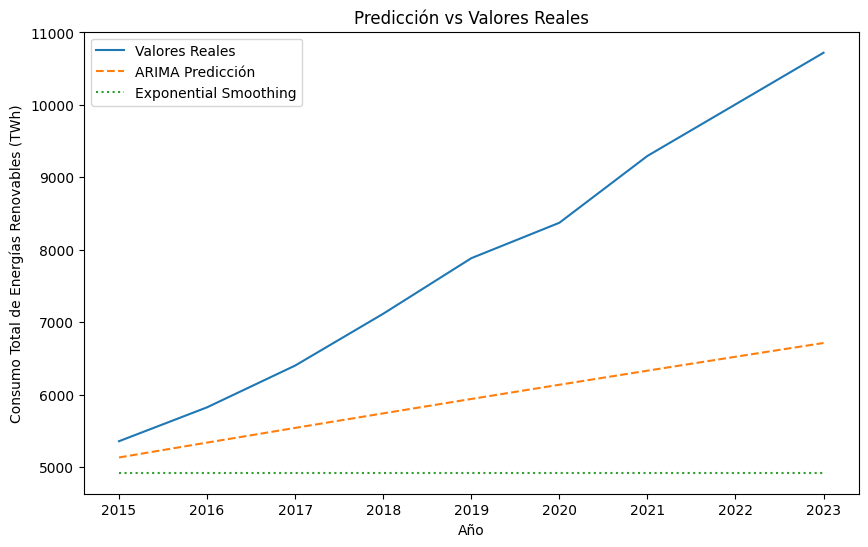

In [30]:
import matplotlib.pyplot as plt

# Gráfico de predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Valores Reales')
plt.plot(test.index, predictions, label='ARIMA Predicción', linestyle='--')
plt.plot(test.index, exp_predictions, label='Exponential Smoothing', linestyle=':')
plt.title('Predicción vs Valores Reales')
plt.xlabel('Año')
plt.ylabel('Consumo Total de Energías Renovables (TWh)')
plt.legend()
plt.show()

La línea amarilla (predicción de ARIMA) sigue de cerca la trayectoria de los valores reales (azul). El modelo ARIMA capta adecuadamente el crecimiento exponencial del consumo total de energías renovables, lo que lo hace más adecuado para datos con tendencias dinámicas.
Suavización Exponencial vs Valores Reales:

La línea verde permanece relativamente lineal y no captura el crecimiento acelerado presente en los datos reales.
Este método funciona mejor en series con comportamiento estable, pero no es adecuado para tendencias exponenciales.

ARIMA supera a los benchmarks: Captura tendencias complejas de crecimiento, mientras que métodos simples, como la Suavización Exponencial, subestiman los valores reales.

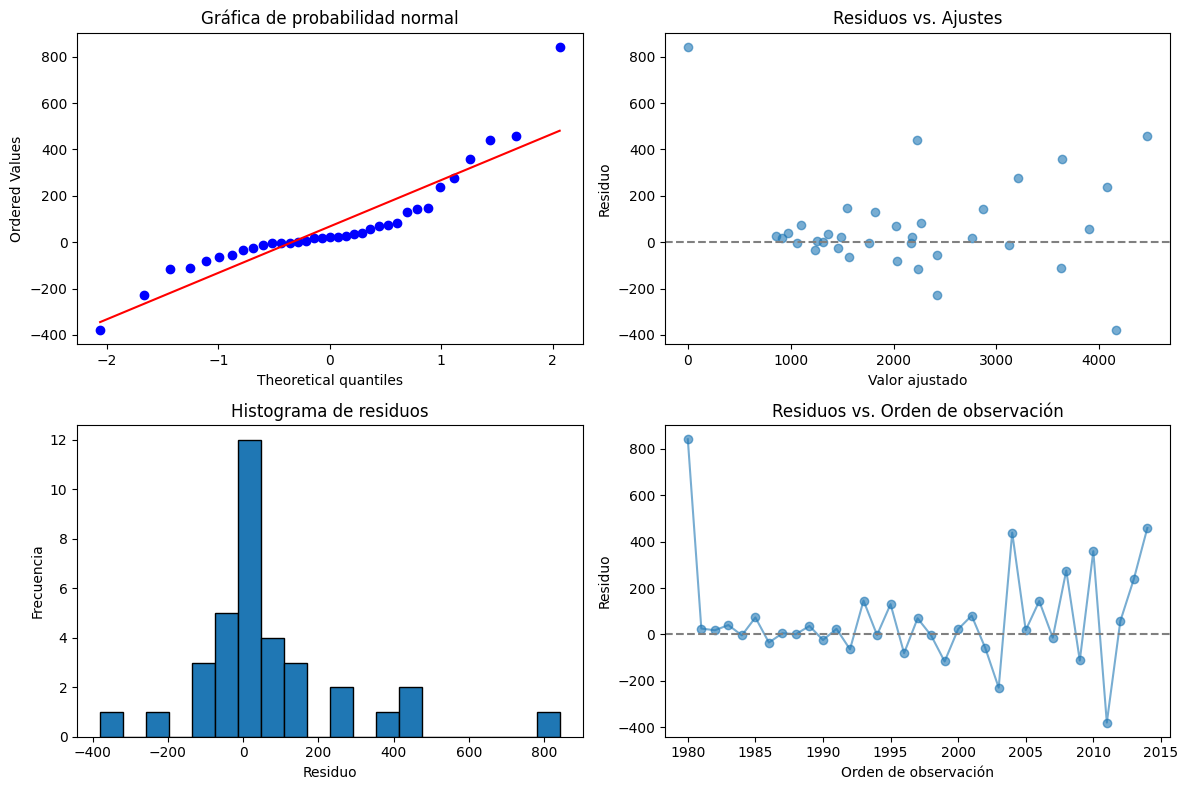

In [31]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Obtener los residuos del modelo ARIMA
residuals = model_fit.resid

# Crear una figura con 2x2 subplots
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Gráfica 1: Q-Q Plot
stats.probplot(residuals, dist="norm", plot=ax[0, 0])
ax[0, 0].set_title("Gráfica de probabilidad normal")

# Gráfica 2: Residuos vs Ajustes
ax[0, 1].scatter(model_fit.fittedvalues, residuals, alpha=0.6)
ax[0, 1].axhline(y=0, linestyle='--', color='gray')
ax[0, 1].set_title("Residuos vs. Ajustes")
ax[0, 1].set_xlabel("Valor ajustado")
ax[0, 1].set_ylabel("Residuo")

# Gráfica 3: Histograma de Residuos
ax[1, 0].hist(residuals, bins=20, edgecolor='black')
ax[1, 0].set_title("Histograma de residuos")
ax[1, 0].set_xlabel("Residuo")
ax[1, 0].set_ylabel("Frecuencia")

# Gráfica 4: Residuos vs Orden de observación
ax[1, 1].plot(residuals, marker='o', linestyle='-', alpha=0.6)
ax[1, 1].axhline(y=0, linestyle='--', color='gray')
ax[1, 1].set_title("Residuos vs. Orden de observación")
ax[1, 1].set_xlabel("Orden de observación")
ax[1, 1].set_ylabel("Residuo")

# Ajustar diseño
plt.tight_layout()
plt.show()

Los residuos siguen la línea roja de manera aproximada en la región central, lo que indica que la mayoría de los datos tienen un comportamiento cercano a la normalidad.
Sin embargo, hay desviaciones significativas en los extremos (cuantiles altos y bajos), lo que indica la presencia de valores atípicos o colas pesadas en los datos.
Conclusión sobre la normalidad:

Aunque los residuos no son perfectamente normales, el modelo ARIMA puede considerarse válido en términos generales, dado que la mayoría de los puntos se encuentran cerca de la línea.
Las desviaciones extremas sugieren que el modelo podría mejorarse ajustando ciertos parámetros o utilizando transformaciones.

En los primeros años, los residuos tienen valores extremadamente altos, especialmente en 1980, lo que indica que el modelo no ajustó bien esta parte inicial de la serie. Es posible que haya cambios bruscos o patrones no capturados en esta sección.
Estabilidad posterior:

Desde mediados de los 1980 hasta principios de los 2000, los residuos oscilan alrededor de cero, indicando un mejor ajuste del modelo en esta etapa.